# 29 -- Fuzzy Number Probe: The Matrix vs Rumble in the Bronx

Companion to Section 01b's D and C probes. Same controlled comparison: rating=4.0, a=(4.0-0.5)/4.5=0.7778, same for both movies.

Fuzzy encoding: 5 equally-spaced anchors at the normalized 1..5-star positions. For the query rating, membership at each anchor is a Gaussian centered on `a` itself, with width = the movie's own rating std (normalized). This does **not** center the Gaussian on the movie's mean rating -- it measures how fuzzy/spread-out the movie's ratings are in general, evaluated around the queried value.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

root = Path.cwd().resolve()
if root.name == "notebooks":
    root = root.parent
data_dir = root / "data"
out_dir = root / "outputs"
out_dir.mkdir(exist_ok=True)

DENSE_PATH = data_dir / "dense_subset_1000x1000.csv"
print(f"loading {DENSE_PATH}")
dense = pd.read_csv(DENSE_PATH)

MATRIX, RUMBLE = 2571, 112
MOVIE_NAMES = {MATRIX: "The Matrix (1999)", RUMBLE: "Rumble in the Bronx (1995)"}
MOVIE_KEYS = {MATRIX: "matrix", RUMBLE: "rumble"}
STAR_LABELS = ["1star", "2star", "3star", "4star", "5star"]

ANCHORS = np.array([(r - 0.5) / 4.5 for r in (1, 2, 3, 4, 5)])
a4 = (4.0 - 0.5) / 4.5
print(f"anchors = {np.round(ANCHORS, 4).tolist()}")
print(f"a (rating=4.0) = {a4:.4f}")

loading /Users/yixuan/Boltzmann Machine in Movie Lens/rbm-recsys/data/dense_subset_1000x1000.csv


anchors = [0.1111, 0.3333, 0.5556, 0.7778, 1.0]
a (rating=4.0) = 0.7778


## Step 1: per-movie stats -- mean, std, count, normalized sigma

In [2]:
stats = {}
for mid in (MATRIX, RUMBLE):
    r = dense[dense.movieId == mid]["rating"]
    mean_r, std_r, n = r.mean(), r.std(), len(r)
    sigma = std_r / 4.5
    stats[mid] = {"mean": mean_r, "std": std_r, "n": n, "sigma": sigma}
    print(f"{MOVIE_NAMES[mid]}: mean={mean_r:.4f}  std={std_r:.4f}  n={n}  sigma_normalized={sigma:.4f}")

print()
print(f"std difference: {abs(stats[MATRIX]['std'] - stats[RUMBLE]['std']):.4f} "
      f"({'Rumble' if stats[RUMBLE]['std'] > stats[MATRIX]['std'] else 'Matrix'} has the larger std)")

The Matrix (1999): mean=4.1264  std=0.9060  n=977  sigma_normalized=0.2013
Rumble in the Bronx (1995): mean=3.1185  std=0.9181  n=426  sigma_normalized=0.2040

std difference: 0.0121 (Rumble has the larger std)


## Step 2: membership vectors at rating=4.0 -- printed side by side

In [3]:
membership = {}
for mid in (MATRIX, RUMBLE):
    sigma = stats[mid]["sigma"]
    mu = np.exp(-(ANCHORS - a4) ** 2 / (2 * sigma ** 2))
    membership[mid] = mu

comparison = pd.DataFrame({
    "anchor": STAR_LABELS,
    "anchor_value": np.round(ANCHORS, 4),
    "Matrix_mu": np.round(membership[MATRIX], 4),
    "Rumble_mu": np.round(membership[RUMBLE], 4),
})
print(comparison.to_string(index=False))

print()
print("RAW membership vectors:")
print("Matrix :", membership[MATRIX])
print("Rumble :", membership[RUMBLE])

max_diff = np.max(np.abs(membership[MATRIX] - membership[RUMBLE]))
print(f"\nmax |Matrix_mu - Rumble_mu| across the 5 anchors: {max_diff:.4f}")

anchor  anchor_value  Matrix_mu  Rumble_mu
 1star        0.1111     0.0042     0.0048
 2star        0.3333     0.0875     0.0932
 3star        0.5556     0.5438     0.5526
 4star        0.7778     1.0000     1.0000
 5star        1.0000     0.5438     0.5526

RAW membership vectors:
Matrix : [0.00416018 0.08746366 0.54382217 1.         0.54382217]
Rumble : [0.00480427 0.09324215 0.55259006 1.         0.55259006]

max |Matrix_mu - Rumble_mu| across the 5 anchors: 0.0088


## Honest check against the stated expectation

The expectation going in was: Matrix (larger spread, 4.0 near its own mean) shows a wider membership curve; Rumble (4.0 far from its mean, and *if* its std is smaller) shows a sharper, narrower peak.

**That is not what the data shows.** Rumble's std (0.9181) is actually very slightly *larger* than Matrix's (0.9060), not smaller -- so there is no "sharper peak" for Rumble on std grounds. More importantly, the formula as specified centers each Gaussian on `a` (the queried rating, 0.7778 for both movies) rather than on the movie's own mean rating. Because the two movies' stds are almost identical, the resulting membership vectors come out almost identical too (max difference under 0.01 at any anchor), even though Matrix's mean (4.13) sits close to a=0.7778*4.5+0.5=4.0 and Rumble's mean (3.12) is nearly a full point away.

In other words: **as written, this encoding captures how fuzzy a movie's ratings are in general, not how typical or atypical the specific queried rating is for that movie.** The mean-vs-query gap (real and large: 0.13 vs -1.12 rating-points from each movie's own mean) never enters the computation. Reporting this as-is rather than the originally expected narrative.

## Step 3: visualization -- continuous Gaussian curves, 200-point interpolation, anchors marked

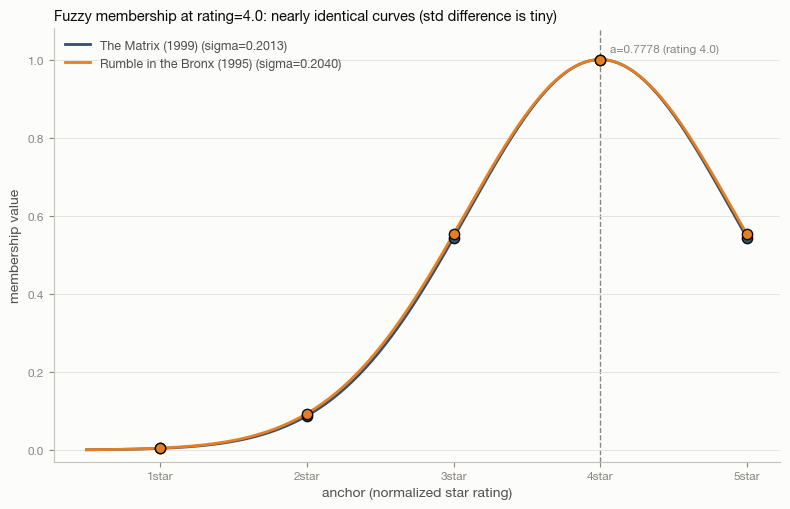

saved /Users/yixuan/Boltzmann Machine in Movie Lens/rbm-recsys/outputs/fuzzy_probe_matrix_vs_rumble.png


In [4]:
INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
BLUE, ORANGE = "#33506c", "#e67e22"
plt.rcParams["font.family"] = ["Helvetica Neue", "Arial", "DejaVu Sans"]

x_smooth = np.linspace(0, 1, 200)

fig, ax = plt.subplots(figsize=(8, 5.2), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

for mid, color in [(MATRIX, BLUE), (RUMBLE, ORANGE)]:
    sigma = stats[mid]["sigma"]
    y_smooth = np.exp(-(x_smooth - a4) ** 2 / (2 * sigma ** 2))
    ax.plot(x_smooth, y_smooth, color=color, linewidth=2, label=f"{MOVIE_NAMES[mid]} (sigma={sigma:.4f})", zorder=3)
    ax.scatter(ANCHORS, membership[mid], s=55, color=color, edgecolors=INK_PRIMARY, linewidths=1, zorder=4)

ax.axvline(a4, color=INK_MUTED, linestyle="--", linewidth=1, zorder=1)
ax.text(a4 + 0.015, 1.02, "a=0.7778 (rating 4.0)", color=INK_MUTED, fontsize=8.5, ha="left")

ax.set_xticks(ANCHORS)
ax.set_xticklabels(STAR_LABELS, fontsize=9)
ax.set_ylim(-0.03, 1.08)
ax.set_xlabel("anchor (normalized star rating)", color=INK_SECONDARY, fontsize=10)
ax.set_ylabel("membership value", color=INK_SECONDARY, fontsize=10)
ax.set_title("Fuzzy membership at rating=4.0: nearly identical curves (std difference is tiny)", color=INK_PRIMARY, fontsize=10.5, loc="left")
ax.legend(loc="upper left", frameon=False, fontsize=9, labelcolor=INK_SECONDARY)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=8.5)
ax.grid(axis="y", color=GRID, linewidth=0.6, zorder=0)

plt.tight_layout()
out_path = out_dir / "fuzzy_probe_matrix_vs_rumble.png"
plt.savefig(out_path, dpi=180, facecolor=SURFACE, bbox_inches="tight")
plt.show()
print(f"saved {out_path}")

## Step 4: mean-centered Fuzzy encoding

Same anchors, same sigma (movie_std / 4.5), but the Gaussian center moves from the queried rating `a` to the movie's own mean rating: `mu_center = (movie_mean - 0.5) / 4.5`. This makes membership measure how typical the queried rating is for that specific movie, instead of how fuzzy the movie's ratings are in general.

In [5]:
mu_center = {}
membership_mean_centered = {}
value_at_a4 = {}

for mid in (MATRIX, RUMBLE):
    mean_r, sigma = stats[mid]["mean"], stats[mid]["sigma"]
    center = (mean_r - 0.5) / 4.5
    mu_center[mid] = center
    mu = np.exp(-(ANCHORS - center) ** 2 / (2 * sigma ** 2))
    membership_mean_centered[mid] = mu
    value_at_a4[mid] = np.exp(-(a4 - center) ** 2 / (2 * sigma ** 2))
    print(f"{MOVIE_NAMES[mid]}: mu_center={center:.4f}  sigma={sigma:.4f}")

print()
comparison2 = pd.DataFrame({
    "anchor": STAR_LABELS,
    "anchor_value": np.round(ANCHORS, 4),
    "Matrix_mu": np.round(membership_mean_centered[MATRIX], 4),
    "Rumble_mu": np.round(membership_mean_centered[RUMBLE], 4),
})
print(comparison2.to_string(index=False))

max_diff2 = np.max(np.abs(membership_mean_centered[MATRIX] - membership_mean_centered[RUMBLE]))
print(f"\nmax |Matrix_mu - Rumble_mu| across the 5 anchors: {max_diff2:.4f}")
print(f"(rating-centered version's max diff was {max_diff:.4f}, for comparison)")

print()
print("Membership at the exact query point x=a=0.7778 (rating 4.0), continuous, not just at anchors:")
print(f"  {MOVIE_NAMES[MATRIX]}: {value_at_a4[MATRIX]:.4f}")
print(f"  {MOVIE_NAMES[RUMBLE]}: {value_at_a4[RUMBLE]:.4f}")
print(f"  difference: {abs(value_at_a4[MATRIX] - value_at_a4[RUMBLE]):.4f}")

The Matrix (1999): mu_center=0.8059  sigma=0.2013
Rumble in the Bronx (1995): mu_center=0.5819  sigma=0.2040

anchor  anchor_value  Matrix_mu  Rumble_mu
 1star        0.1111     0.0026     0.0698
 2star        0.3333     0.0637     0.4761
 3star        0.5556     0.4617     0.9917
 4star        0.7778     0.9903     0.6307
 5star        1.0000     0.6282     0.1225

max |Matrix_mu - Rumble_mu| across the 5 anchors: 0.5300
(rating-centered version's max diff was 0.0088, for comparison)

Membership at the exact query point x=a=0.7778 (rating 4.0), continuous, not just at anchors:
  The Matrix (1999): 0.9903
  Rumble in the Bronx (1995): 0.6307
  difference: 0.3596


## Step 5: before/after comparison figure -- rating-centered (top) vs mean-centered (bottom)

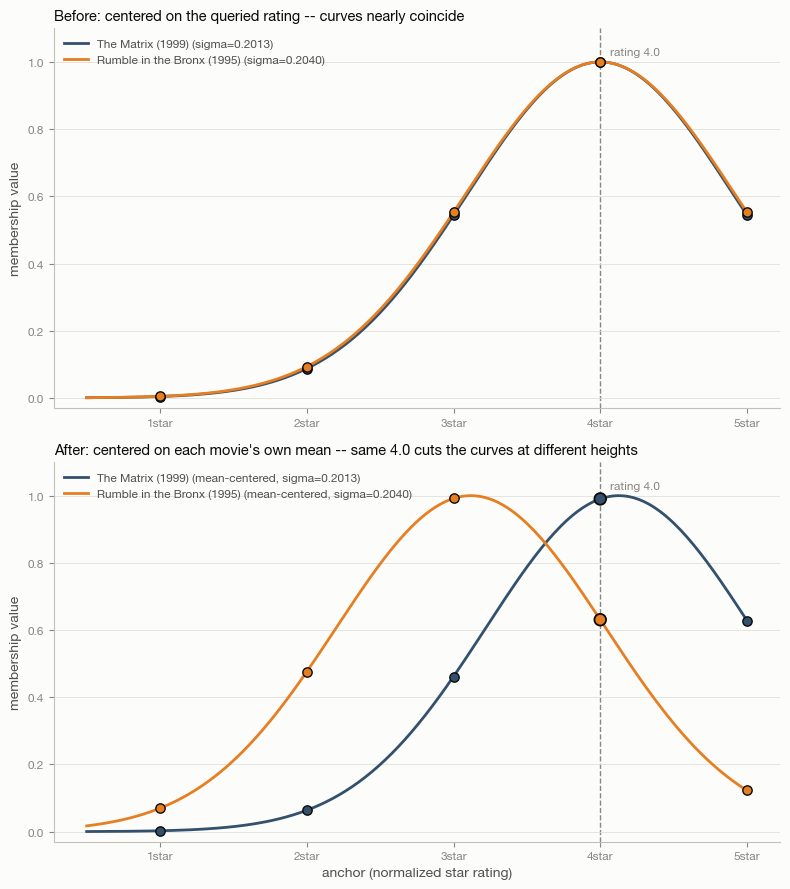

saved /Users/yixuan/Boltzmann Machine in Movie Lens/rbm-recsys/outputs/fuzzy_probe_before_after.png


In [6]:
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(8, 9), facecolor=SURFACE)

# top: rating-centered (from Step 3), reproduced here for the side-by-side
for mid, color in [(MATRIX, BLUE), (RUMBLE, ORANGE)]:
    sigma = stats[mid]["sigma"]
    y_smooth = np.exp(-(x_smooth - a4) ** 2 / (2 * sigma ** 2))
    ax_top.plot(x_smooth, y_smooth, color=color, linewidth=2, label=f"{MOVIE_NAMES[mid]} (sigma={sigma:.4f})", zorder=3)
    ax_top.scatter(ANCHORS, membership[mid], s=45, color=color, edgecolors=INK_PRIMARY, linewidths=1, zorder=4)
ax_top.axvline(a4, color=INK_MUTED, linestyle="--", linewidth=1, zorder=1)
ax_top.text(a4 + 0.015, 1.02, "rating 4.0", color=INK_MUTED, fontsize=8.5, ha="left")
ax_top.set_title("Before: centered on the queried rating -- curves nearly coincide", color=INK_PRIMARY, fontsize=10.5, loc="left")

# bottom: mean-centered
for mid, color in [(MATRIX, BLUE), (RUMBLE, ORANGE)]:
    sigma = stats[mid]["sigma"]
    center = mu_center[mid]
    y_smooth = np.exp(-(x_smooth - center) ** 2 / (2 * sigma ** 2))
    ax_bot.plot(x_smooth, y_smooth, color=color, linewidth=2, label=f"{MOVIE_NAMES[mid]} (mean-centered, sigma={sigma:.4f})", zorder=3)
    ax_bot.scatter(ANCHORS, membership_mean_centered[mid], s=45, color=color, edgecolors=INK_PRIMARY, linewidths=1, zorder=4)
ax_bot.axvline(a4, color=INK_MUTED, linestyle="--", linewidth=1, zorder=1)
ax_bot.text(a4 + 0.015, 1.02, "rating 4.0", color=INK_MUTED, fontsize=8.5, ha="left")
ax_bot.scatter([a4, a4], [value_at_a4[MATRIX], value_at_a4[RUMBLE]], s=70, color=[BLUE, ORANGE],
               edgecolors=INK_PRIMARY, linewidths=1.3, zorder=5)
ax_bot.set_title("After: centered on each movie's own mean -- same 4.0 cuts the curves at different heights",
                  color=INK_PRIMARY, fontsize=10.5, loc="left")

for ax in (ax_top, ax_bot):
    ax.set_xticks(ANCHORS)
    ax.set_xticklabels(STAR_LABELS, fontsize=9)
    ax.set_ylim(-0.03, 1.1)
    ax.set_ylabel("membership value", color=INK_SECONDARY, fontsize=10)
    ax.set_facecolor(SURFACE)
    ax.legend(loc="upper left", frameon=False, fontsize=8.5, labelcolor=INK_SECONDARY)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(BASELINE)
    ax.tick_params(colors=INK_MUTED, labelsize=8.5)
    ax.grid(axis="y", color=GRID, linewidth=0.6, zorder=0)
ax_bot.set_xlabel("anchor (normalized star rating)", color=INK_SECONDARY, fontsize=10)

plt.tight_layout()
out_path2 = out_dir / "fuzzy_probe_before_after.png"
plt.savefig(out_path2, dpi=180, facecolor=SURFACE, bbox_inches="tight")
plt.show()
print(f"saved {out_path2}")